In [1]:
from google.colab import files
uploaded = files.upload()

Saving california.csv to california.csv
Saving artificial1d.csv to artificial1d.csv
Saving vehicle.csv to vehicle.csv
Saving breastcancer.csv to breastcancer.csv


In [2]:
import pandas as pd

# Ler o arquivo
df_california = pd.read_csv('california.csv')

# Exibir todas as colunas
print("Colunas do california.csv:")
print(df_california.columns.tolist())

# Número de linhas e colunas
linhas, colunas = df_california.shape
print(f"\nNúmero de linhas: {linhas}")
print(f"Número de colunas: {colunas}")

Colunas do california.csv:
['4.168499999999999872e+00', '2.000000000000000000e+01', '6.700636942675159524e+00', '1.178343949044585948e+00', '7.450000000000000000e+02', '2.372611464968152895e+00', '3.879999999999999716e+01', '-1.211500000000000057e+02', '2.174999999999999822e+00']

Número de linhas: 999
Número de colunas: 9


In [3]:
import pandas as pd

# Ler o arquivo
df_artificial = pd.read_csv('artificial1d.csv')

# Exibir todas as colunas
print("Colunas do artificial1d.csv:")
print(df_artificial.columns.tolist())

# Número de linhas e colunas
linhas, colunas = df_artificial.shape
print(f"\nNúmero de linhas: {linhas}")
print(f"Número de colunas: {colunas}")

Colunas do artificial1d.csv:
['-1.000000000000000000e+00', '-2.082017257233804042e+00']

Número de linhas: 29
Número de colunas: 2


In [4]:
import pandas as pd

# Ler o arquivo
df_vehicle = pd.read_csv('vehicle.csv')

# Exibir todas as colunas
print("Colunas do vehicle.csv:")
print(df_vehicle.columns.tolist())

# Número de linhas e colunas
linhas, colunas = df_vehicle.shape
print(f"\nNúmero de linhas: {linhas}")
print(f"Número de colunas: {colunas}")

Colunas do vehicle.csv:
['9.500000000000000000e+01', '4.800000000000000000e+01', '8.300000000000000000e+01', '1.780000000000000000e+02', '7.200000000000000000e+01', '1.000000000000000000e+01', '1.620000000000000000e+02', '4.200000000000000000e+01', '2.000000000000000000e+01', '1.590000000000000000e+02', '1.760000000000000000e+02', '3.790000000000000000e+02', '1.840000000000000000e+02', '7.000000000000000000e+01', '6.000000000000000000e+00', '1.600000000000000000e+01', '1.870000000000000000e+02', '1.970000000000000000e+02', '3.000000000000000000e+00']

Número de linhas: 845
Número de colunas: 19


In [5]:
import pandas as pd

# Ler o arquivo
df_breast = pd.read_csv('breastcancer.csv')

# Exibir todas as colunas
print("Colunas do breastcancer.csv:")
print(df_breast.columns.tolist())

# Número de linhas e colunas
linhas, colunas = df_breast.shape
print(f"\nNúmero de linhas: {linhas}")
print(f"Número de colunas: {colunas}")

Colunas do breastcancer.csv:
['1.798999999999999844e+01', '1.038000000000000078e+01', '1.227999999999999972e+02', '1.001000000000000000e+03', '1.184000000000000052e-01', '2.776000000000000134e-01', '3.000999999999999779e-01', '1.471000000000000085e-01', '2.419000000000000039e-01', '7.871000000000000218e-02', '1.094999999999999973e+00', '9.052999999999999936e-01', '8.589000000000000412e+00', '1.534000000000000057e+02', '6.399000000000000174e-03', '4.904000000000000026e-02', '5.372999999999999998e-02', '1.586999999999999869e-02', '3.003000000000000114e-02', '6.192999999999999720e-03', '2.537999999999999901e+01', '1.732999999999999829e+01', '1.845999999999999943e+02', '2.019000000000000000e+03', '1.622000000000000108e-01', '6.655999999999999694e-01', '7.118999999999999773e-01', '2.654000000000000248e-01', '4.601000000000000090e-01', '1.189000000000000057e-01', '1.000000000000000000e+00']

Número de linhas: 568
Número de colunas: 31


**Questão 1**

Considere o conjunto de dados disponível em artificial1d.csv organizado em
duas colunas, x e y. Seja um modelo de regressão linear para yˆ = f(x).

a) Apresente os parâmetros do modelo e o MSE (erro quadrático médio)
obtidos pelo algoritmo OLS (mínimos quadrados ordinários). Plote
a reta resultante sobre os dados.

b) Apresente os parâmetros do modelo, o MSE e a curva de aprendizagem
obtidos pelo algoritmo GD (gradiente descendente). Plote a reta resultante sobre os dados.

c) Apresente os parâmetros do modelo, o MSE e a curva de aprendizagem
obtidos pelo algoritmo SGD (gradiente descendente estocástico).
Plote a reta resultante sobre os dados.

In [16]:
# O objetivo: desta célula é preparar os dados para os três métodos de regressão
# linear, garantindo que o modelo inclua um termo de viés. de acordo com a condição
# da questão: "Considere o conjunto de dados disponível em artificial1d.csv organizado
# em duas colunas, x e y. Seja um modelo de regressão linear para yˆ = f(x)."

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# O arquivo 'artificial1d.csv' não possui cabeçalho/nomes de colunas,
# carreguei com header=None e atribuí manualmente os nomes 'x' e 'y'.
df = pd.read_csv('artificial1d.csv', header=None, names=['x', 'y'])

# Verifiquei visualmente os primeiros registros para garantir que os dados foram lidos corretamente.
print("Primeiras linhas:")
print(df.head())

# Extraindo as variáveis:
# - X: matriz de entrada (features), com uma única coluna 'x'
# - y: vetor alvo (rótulos)
X = df[['x']].values   # shape (n, 1)
y = df['y'].values     # shape (n,)

# Para implementar regressão linear com viés (bias/intercepto),
# adicionei uma coluna de 1s (bias) à matriz X, formando X_b (X com bias).
# Assim, o modelo será: y_hat = θ0 * 1 + θ1 * x = θ0 + θ1*x
X_b = np.c_[np.ones((X.shape[0], 1)), X]  # shape (n, 2)

print(f"\nDados carregados com sucesso!")
print(f"Número de amostras: {X.shape[0]}")
print(f"Dimensão de X: {X.shape}, dimensão de y: {y.shape}")

Primeiras linhas:
          x         y
0 -1.000000 -2.082017
1 -0.931034 -1.326980
2 -0.862069 -1.105598
3 -0.793103 -0.873946
4 -0.724138 -0.285027

Dados carregados com sucesso!
Número de amostras: 30
Dimensão de X: (30, 1), dimensão de y: (30,)


=== OLS (Mínimos Quadrados Ordinários) ===
Parâmetros do modelo: θ0 (viés) = 0.067618, θ1 (inclinação) = 1.574865
Erro Quadrático Médio (MSE): 0.21340090


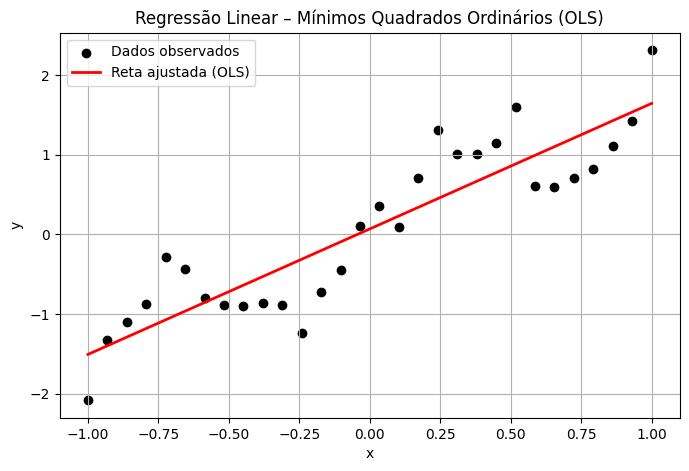

In [17]:
#a) Apresente os parâmetros do modelo e o MSE (erro quadrático médio) obtidos pelo algoritmo
# OLS (mínimos quadrados ordinários). Plote a reta resultante sobre os dados.

#---------------------------------------------------------------------------------------------------------------

# OLS (Ordinary Least Squares) fornece a solução analítica exata para regressão linear.
# A fórmula é: θ = (X^T X)^(-1) X^T y
# Essa solução minimiza globalmente o erro quadrático médio (MSE).
theta_ols = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

# Calculando as previsões do modelo: y_hat = X_b * θ
y_pred_ols = X_b.dot(theta_ols)

# Calculando o MSE: média dos quadrados dos erros (y - y_hat)
mse_ols = np.mean((y - y_pred_ols) ** 2)

print("=== OLS (Mínimos Quadrados Ordinários) ===")
print(f"Parâmetros do modelo: θ0 (viés) = {theta_ols[0]:.6f}, θ1 (inclinação) = {theta_ols[1]:.6f}")
print(f"Erro Quadrático Médio (MSE): {mse_ols:.8f}")

# Plotando os dados originais (pontos pretos) e a reta ajustada pelo OLS (linha vermelha)
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='black', label='Dados observados')
plt.plot(X, y_pred_ols, color='red', linewidth=2, label='Reta ajustada (OLS)')
plt.title('Regressão Linear – Mínimos Quadrados Ordinários (OLS)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

=== GD (Gradient Descent em Batch) ===
Parâmetros do modelo: θ0 = 0.067618, θ1 = 1.574085
MSE final após 1000 iterações: 0.21340112


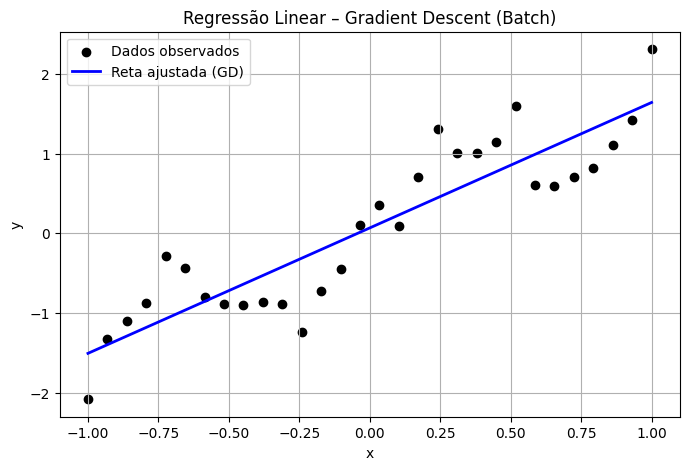

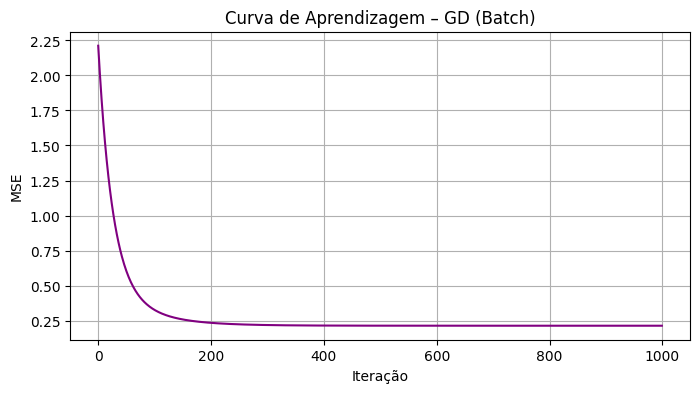

In [19]:
# b) Apresente os parâmetros do modelo, o MSE e a curva de aprendizagem obtidos pelo algoritmo GD (gradiente
# descendente). Plote a reta resultante sobre os dados.

#---------------------------------------------------------------------------------------------------------------------

# Gradient Descent (GD) é um método que atualiza os parâmetros na direção oposta ao gradiente do MSE.
# Usamos o GD em modo "batch" e todo o conjunto de dados é usado a cada iteração.

learning_rate = 0.01      # Taxa de aprendizado: controla o tamanho do passo
n_iterations = 1000       # Número de iterações
m = len(y)                # Número de amostras

# Inicializando os parâmetros aleatoriamente (ou poderia usar zeros)
theta_gd = np.random.randn(2)
mse_history_gd = []       # Listar para armazenar o MSE a cada iteração (curva de aprendizagem)

for i in range(n_iterations):
    # Gradiente do MSE em relação a θ: ∇MSE = (2/m) * X^T (Xθ - y)
    gradients = (2/m) * X_b.T.dot(X_b.dot(theta_gd) - y)
    # Atualização dos parâmetros
    theta_gd = theta_gd - learning_rate * gradients

    # Calculando o MSE atual para monitorar a convergência
    mse = np.mean((y - X_b.dot(theta_gd)) ** 2)
    mse_history_gd.append(mse)

# Após o treinamento, calculei as previsões finais e o MSE final
y_pred_gd = X_b.dot(theta_gd)
mse_gd = mse_history_gd[-1]

print("=== GD (Gradient Descent em Batch) ===")
print(f"Parâmetros do modelo: θ0 = {theta_gd[0]:.6f}, θ1 = {theta_gd[1]:.6f}")
print(f"MSE final após {n_iterations} iterações: {mse_gd:.8f}")

# Plot da reta ajustada
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='black', label='Dados observados')
plt.plot(X, y_pred_gd, color='blue', linewidth=2, label='Reta ajustada (GD)')
plt.title('Regressão Linear – Gradient Descent (Batch)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# Curva de aprendizagem: mostra como o erro diminui ao longo das iterações
plt.figure(figsize=(8, 4))
plt.plot(mse_history_gd, color='purple')
plt.title('Curva de Aprendizagem – GD (Batch)')
plt.xlabel('Iteração')
plt.ylabel('MSE')
plt.grid(True)
plt.show()

=== SGD (Stochastic Gradient Descent) ===
Parâmetros do modelo: θ0 = 0.078960, θ1 = 1.570233
MSE final após 100 épocas: 0.21353719


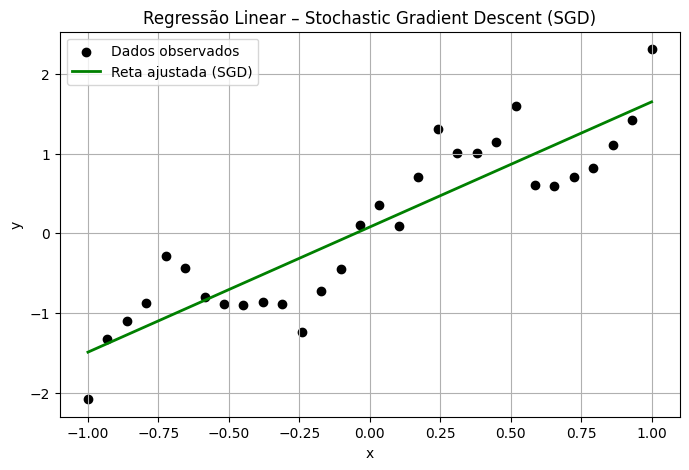

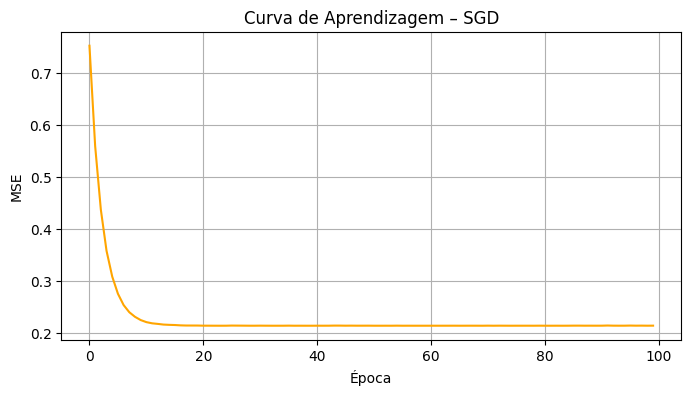

In [20]:
#c) Apresente os parâmetros do modelo, o MSE e a curva de aprendizagem obtidos pelo algoritmo
#SGD (gradiente descendente estocástico). Plote a reta resultante sobre os dados.

#------------------------------------------------------------------------------------------------

from sklearn.utils import shuffle  # Para embaralhar os dados a cada época

# Stochastic Gradient Descent (SGD) atualiza os parâmetros usando UM exemplo por vez,
# tornando o processo mais ruidoso, mais rápido por iteração.

learning_rate = 0.01
n_epochs = 100   # Número de épocas (passadas completas pelo conjunto de dados)
m = len(y)

theta_sgd = np.random.randn(2)
mse_history_sgd = []

for epoch in range(n_epochs):
    # Embaralhando os dados a cada época para evitar viés na ordem de atualização
    X_b_shuffled, y_shuffled = shuffle(X_b, y, random_state=epoch)

    # Atualização estocástica: um exemplo por vez
    for i in range(m):
        xi = X_b_shuffled[i:i+1]  # shape (1, 2)
        yi = y_shuffled[i:i+1]    # shape (1,)

        # Gradiente baseado em uma única amostra
        gradient = 2 * xi.T.dot(xi.dot(theta_sgd) - yi)
        theta_sgd = theta_sgd - learning_rate * gradient

    # Avaliando o MSE no conjunto completo ao final de cada época
    mse_epoch = np.mean((y - X_b.dot(theta_sgd)) ** 2)
    mse_history_sgd.append(mse_epoch)

# Resultado final
y_pred_sgd = X_b.dot(theta_sgd)
mse_sgd = mse_history_sgd[-1]

print("=== SGD (Stochastic Gradient Descent) ===")
print(f"Parâmetros do modelo: θ0 = {theta_sgd[0]:.6f}, θ1 = {theta_sgd[1]:.6f}")
print(f"MSE final após {n_epochs} épocas: {mse_sgd:.8f}")

# Plot da reta ajustada
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='black', label='Dados observados')
plt.plot(X, y_pred_sgd, color='green', linewidth=2, label='Reta ajustada (SGD)')
plt.title('Regressão Linear – Stochastic Gradient Descent (SGD)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# Curva de aprendizagem do SGD (mais ruidosa que a do GD)
plt.figure(figsize=(8, 4))
plt.plot(mse_history_sgd, color='orange')
plt.title('Curva de Aprendizagem – SGD')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.grid(True)
plt.show()

In [21]:
print("\n" + "="*50)
print("COMPARAÇÃO DOS MÉTODOS")
print("="*50)
print(f"OLS  → θ0 = {theta_ols[0]:.6f}, θ1 = {theta_ols[1]:.6f}, MSE = {mse_ols:.8f}")
print(f"GD   → θ0 = {theta_gd[0]:.6f}, θ1 = {theta_gd[1]:.6f}, MSE = {mse_gd:.8f}")
print(f"SGD  → θ0 = {theta_sgd[0]:.6f}, θ1 = {theta_sgd[1]:.6f}, MSE = {mse_sgd:.8f}")


COMPARAÇÃO DOS MÉTODOS
OLS  → θ0 = 0.067618, θ1 = 1.574865, MSE = 0.21340090
GD   → θ0 = 0.067618, θ1 = 1.574085, MSE = 0.21340112
SGD  → θ0 = 0.078960, θ1 = 1.570233, MSE = 0.21353719


 **Questão 2**

Considere o conjunto de dados disponível em california.csv, organizado em 9
colunas, sendo as 8 primeiras colunas os atributos e a última coluna a saída.
Os 8 atributos são usados na predição da mediana de preços de casas em distritos da Califórnia na década de 1990. Maiores detalhes sobre os dados podem ser conferidos em https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset.

a) Aleatoriamente, divida o conjunto de dados em treino (80%) e teste (20%).

b) Treine 13 modelos de regressão polinomial, com ordens de 1 a 13. Você
pode usar o algoritmo OLS.


In [30]:
# Primeiramente vamos respeitar as condições do enunciado do exercício:
# Considere o conjunto de dados disponível em california.csv, organizado em 9 colunas, sendo
# as 8 primeiras colunas os atributos e a última coluna a saída.

#---------------------------------------------------------------------------------------------

import pandas as pd
import numpy as np

# Carregando o arquivo
df = pd.read_csv('california.csv')

# Verificando que há 9 colunas
assert df.shape[1] == 9, "O dataset deve ter exatamente 9 colunas (8 atributos + 1 saída)."

# Separando atributos (X) e saída (y)
X = df.iloc[:, :-1].values  # primeiras 8 colunas
y = df.iloc[:, -1].values   # última coluna

print(f"Forma do conjunto de dados:")
print(f"- X (atributos): {X.shape}")
print(f"- y (saída):     {y.shape}")

Forma do conjunto de dados:
- X (atributos): (999, 8)
- y (saída):     (999,)


In [24]:
# a) Aleatoriamente, divida o conjunto de dados em treino (80%) e teste (20%).

# -----------------------------------------------------------------------------------

# Dividir aleatoriamente os dados em conjunto de treino (80%) e teste (20%)
# random_state=42 garante reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% para teste
    random_state=42,    # semente para reprodutibilidade
    shuffle=True        # embaralhar (aleatoriedade) antes de dividir
)

print(f"Conjunto de treino: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Conjunto de teste:  X_test  = {X_test.shape},  y_test  = {y_test.shape}")

Conjunto de treino: X_train = (799, 8), y_train = (799,)
Conjunto de teste:  X_test  = (200, 8),  y_test  = (200,)


In [31]:
# b) Treine 13 modelos de regressão polinomial, com ordens de 1 a 13. Você
# pode usar o algoritmo OLS.

# ------------------------------------------------------------------------------


from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

degrees = list(range(1, 14))

# Listas para armazenar os modelos e previsões (ainda normalizadas)
models_ols = []
y_train_pred_scaled_list = []
y_test_pred_scaled_list = []

print("Treinando modelos polinomiais com OLS (graus 1 a 13)...")

for degree in degrees:
    # 1. Gerar features polinomiais a partir de X normalizado
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    # 2. Treinar modelo de regressão linear (OLS) com y normalizado
    model = LinearRegression()
    model.fit(X_train_poly, y_train_scaled)

    # 3. Armazenar modelo e previsões
    models_ols.append(model)

    y_train_pred_scaled = model.predict(X_train_poly)
    y_test_pred_scaled = model.predict(X_test_poly)

    y_train_pred_scaled_list.append(y_train_pred_scaled)
    y_test_pred_scaled_list.append(y_test_pred_scaled)

print("Treinamento concluído para todos os graus.")

Treinando modelos polinomiais com OLS (graus 1 a 13)...
Treinamento concluído para todos os graus.


Calculando RMSE (após desnormalização da saída)...

Grau | RMSE Treino | RMSE Teste
-----------------------------------
   1 |      0.6286 |      0.8215
   2 |      0.5440 |      0.8114
   3 |      0.4595 |     14.5315
   4 |      0.2880 |    237.0464
   5 |      0.0000 |  17870.3739
   6 |      0.0000 |   2485.0715
   7 |      0.0000 |   4361.3356
   8 |      0.0000 |   5543.4699
   9 |      0.0000 |   4747.4207
  10 |      0.0000 |   2219.4718
  11 |      0.0000 |   1222.2580
  12 |      0.0000 |   5355.7037
  13 |      0.0000 |  10435.0452


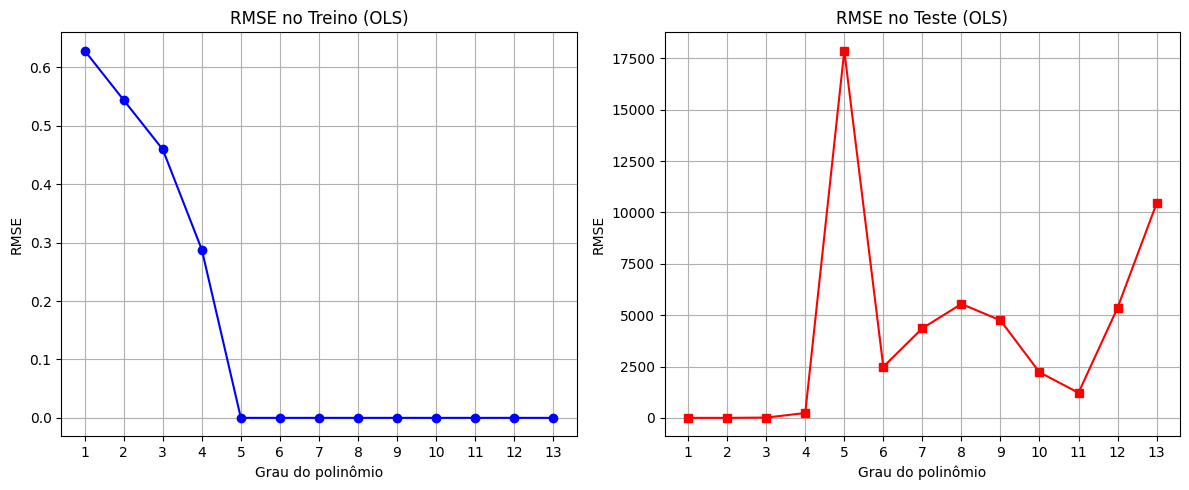

In [32]:
# c) Reporte o RMSE (raiz quadrada do erro quadrático médio) no treinamento
# e no teste para cada modelo. Faça um gráfico para o treino e um gráfico
# para o teste.

#-----------------------------------------------------------------------------------------

# OBS:. Calcular RMSE no treino e no teste, após DESNORMALIZAR as previsões

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

train_rmse_ols = []
test_rmse_ols = []

print("Calculando RMSE (após desnormalização da saída)...")

for i, degree in enumerate(degrees):
    # Desnormalizar as previsões usando o scaler_y
    y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled_list[i].reshape(-1, 1)).ravel()
    y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled_list[i].reshape(-1, 1)).ravel()

    # Calcular RMSE na escala original do alvo
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_rmse_ols.append(rmse_train)
    test_rmse_ols.append(rmse_test)

# Exibir tabela de RMSE
print("\nGrau | RMSE Treino | RMSE Teste")
print("-" * 35)
for i, d in enumerate(degrees):
    print(f"{d:4d} | {train_rmse_ols[i]:11.4f} | {test_rmse_ols[i]:11.4f}")

# Gráfico: RMSE no treino
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(degrees, train_rmse_ols, 'o-', color='blue')
plt.title('RMSE no Treino (OLS)')
plt.xlabel('Grau do polinômio')
plt.ylabel('RMSE')
plt.grid(True)
plt.xticks(degrees)

# Gráfico: RMSE no teste
plt.subplot(1, 2, 2)
plt.plot(degrees, test_rmse_ols, 's-', color='red')
plt.title('RMSE no Teste (OLS)')
plt.xlabel('Grau do polinômio')
plt.ylabel('RMSE')
plt.grid(True)
plt.xticks(degrees)

plt.tight_layout()
plt.show()

In [34]:
# d parte 1) Repita os 2 itens anteriores incluindo um termo de regularização L2
# (por exemplo, com fator λ = 0.01).

#----------------------------------------------------------------------------------------


from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# Hiperparâmetro de regularização
lambda_l2 = 0.01

degrees = list(range(1, 14))

# Listas para armazenar modelos e previsões (na escala normalizada)
models_ridge = []
y_train_pred_scaled_ridge = []
y_test_pred_scaled_ridge = []

print(f"Treinando modelos polinomiais com regularização L2 (Ridge, λ = {lambda_l2})...")

for degree in degrees:
    # 1. Gerar features polinomiais a partir de X normalizado
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    # 2. Treinar modelo Ridge com y normalizado
    model = Ridge(alpha=lambda_l2)  # alpha = λ
    model.fit(X_train_poly, y_train_scaled)

    # 3. Armazenar previsões (ainda na escala normalizada)
    y_train_pred_scaled = model.predict(X_train_poly)
    y_test_pred_scaled = model.predict(X_test_poly)

    models_ridge.append(model)
    y_train_pred_scaled_ridge.append(y_train_pred_scaled)
    y_test_pred_scaled_ridge.append(y_test_pred_scaled)

print("Treinamento com regularização L2 concluído para todos os graus.")

Treinando modelos polinomiais com regularização L2 (Ridge, λ = 0.01)...
Treinamento com regularização L2 concluído para todos os graus.


Calculando RMSE com regularização L2 (após desnormalização)...

Grau | RMSE Treino (Ridge) | RMSE Teste (Ridge)
--------------------------------------------------
   1 |              0.6286 |               0.8212
   2 |              0.5570 |               0.7776
   3 |              0.5264 |               0.7444
   4 |              0.5082 |               0.9046
   5 |              0.4991 |               1.4262
   6 |              0.4935 |               1.8868
   7 |              0.4891 |               2.0669
   8 |              0.4855 |               1.8083
   9 |              0.4825 |               1.0063
  10 |              0.4800 |               1.5877
  11 |              0.4778 |               5.2483
  12 |              0.4758 |              11.8674
  13 |              0.4741 |              23.2061


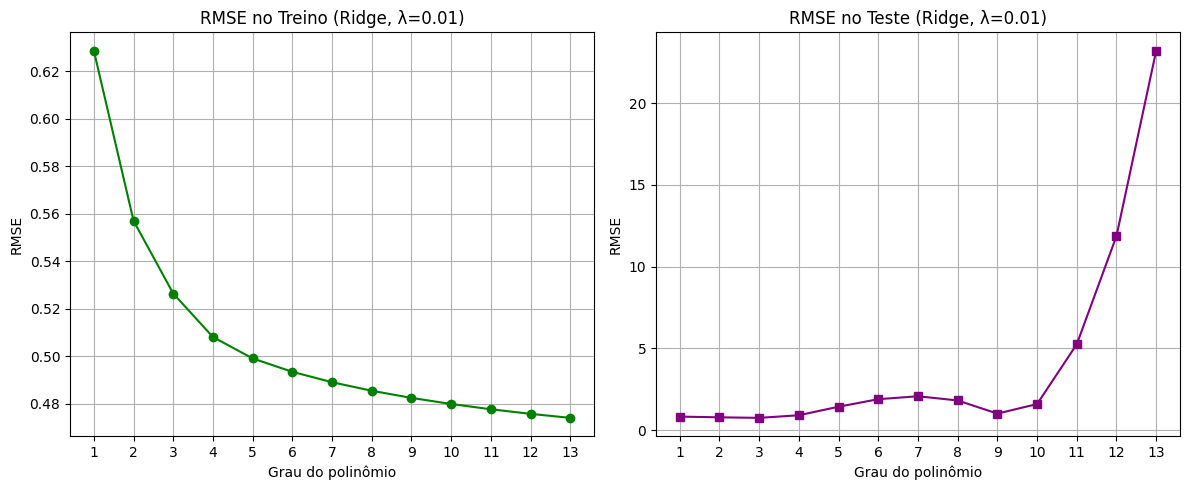


Melhor grau com Ridge (λ=0.01): 3 (RMSE = 0.7444)


In [35]:
# d parte 2) Repita os 2 itens anteriores incluindo um termo de regularização L2
# (por exemplo, com fator λ = 0.01).
#Cálculo do  RMSE após desnormalizar as previsões

#----------------------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

train_rmse_ridge = []
test_rmse_ridge = []

print("Calculando RMSE com regularização L2 (após desnormalização)...")

for i, degree in enumerate(degrees):
    # Desnormalizar as previsões usando o scaler_y ajustado anteriormente
    y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled_ridge[i].reshape(-1, 1)).ravel()
    y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled_ridge[i].reshape(-1, 1)).ravel()

    # Calcular RMSE na escala original do alvo
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_rmse_ridge.append(rmse_train)
    test_rmse_ridge.append(rmse_test)

# Exibir tabela de RMSE
print("\nGrau | RMSE Treino (Ridge) | RMSE Teste (Ridge)")
print("-" * 50)
for i, d in enumerate(degrees):
    print(f"{d:4d} | {train_rmse_ridge[i]:19.4f} | {test_rmse_ridge[i]:20.4f}")

# Gráficos: RMSE no treino e no teste com regularização L2
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(degrees, train_rmse_ridge, 'o-', color='green')
plt.title('RMSE no Treino (Ridge, λ=0.01)')
plt.xlabel('Grau do polinômio')
plt.ylabel('RMSE')
plt.grid(True)
plt.xticks(degrees)

plt.subplot(1, 2, 2)
plt.plot(degrees, test_rmse_ridge, 's-', color='purple')
plt.title('RMSE no Teste (Ridge, λ=0.01)')
plt.xlabel('Grau do polinômio')
plt.ylabel('RMSE')
plt.grid(True)
plt.xticks(degrees)

plt.tight_layout()
plt.show()

# Identificar melhor grau com regularização
best_degree_ridge = degrees[np.argmin(test_rmse_ridge)]
print(f"\nMelhor grau com Ridge (λ={lambda_l2}): {best_degree_ridge} (RMSE = {min(test_rmse_ridge):.4f})")

**Questão 3**

Considere o conjunto de dados disponível em breastcancer.csv, organizado
em 31 colunas, sendo as 30 primeiras colunas os atributos e a última coluna a
saída. Os 30 atributos coletados de exames médicos são usados no diagnóstico
do câncer de mama, sendo 1 a classe positiva e 0 a classe negativa. Maiores
detalhes sobre os dados podem ser conferidos em https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset.

a) Considerando uma validação cruzada em 10 folds, avalie um modelo de
Regressão Logística (treinado com GD ou SGD) nos dados em questão.

b) Reporte valor médio e desvio padrão da acurácia global e da acurácia
por classe.


In [37]:
# a) Considerando uma validação cruzada em 10 folds, avalie um modelo de
# Regressão Logística (treinado com GD ou SGD) nos dados em questão.

#-----------------------------------------------------------------------------------------

from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score

# Carregar o dataset
df = pd.read_csv('breastcancer.csv')

# Separar atributos e rótulos
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Garantir que y seja inteiro (0 e 1 como inteiros, não floats)
y = y.astype(int)

print(f"Tipo de y: {y.dtype}")
print(f"Classes únicas: {np.unique(y)}")

# Configurando validação cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Modelo: Regressão Logística via SGD
# loss='log_loss' → regressão logística
# max_iter e tol ajustados para convergência estável
model = SGDClassifier(
    loss='log_loss',
    learning_rate='constant',
    eta0=0.01,
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

# Métricas: acurácia global + acurácia por classe
# Para acurácia por classe, usaremos uma função personalizada
def class_accuracies(y_true, y_pred):
    # Classe 0 (negativa)
    acc_0 = accuracy_score(y_true[y_true == 0], y_pred[y_true == 0]) if (y_true == 0).any() else 0
    # Classe 1 (positiva)
    acc_1 = accuracy_score(y_true[y_true == 1], y_pred[y_true == 1]) if (y_true == 1).any() else 0
    return {'acc_class_0': acc_0, 'acc_class_1': acc_1}

# Como cross_validate não suporta métricas por classe diretamente,
# fiz a CV manualmente para coletar acurácias por classe
from sklearn.base import clone

global_accuracies = []
class0_accuracies = []
class1_accuracies = []

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Treinando modelo
    clf = clone(model)
    clf.fit(X_train, y_train)

    # Prevendo
    y_pred = clf.predict(X_test)

    # Acurácia global
    global_acc = accuracy_score(y_test, y_pred)
    global_accuracies.append(global_acc)

    # Acurácias por classe
    accs = class_accuracies(y_test, y_pred)
    class0_accuracies.append(accs['acc_class_0'])
    class1_accuracies.append(accs['acc_class_1'])

print("Validação cruzada concluída com 10 folds.")

Tipo de y: int64
Classes únicas: [0 1]
Validação cruzada concluída com 10 folds.


In [38]:
# b) Reporte valor médio e desvio padrão da acurácia global e da acurácia
# por classe.

#-----------------------------------------------------------------------------------

# Convertendo listas para arrays NumPy
global_accuracies = np.array(global_accuracies)
class0_accuracies = np.array(class0_accuracies)
class1_accuracies = np.array(class1_accuracies)

# Calculando média e desvio padrão
mean_global = global_accuracies.mean()
std_global = global_accuracies.std()

mean_class0 = class0_accuracies.mean()
std_class0 = class0_accuracies.std()

mean_class1 = class1_accuracies.mean()
std_class1 = class1_accuracies.std()

# Exibindo resultados
print("=== Resultados da Validação Cruzada (10-Fold) ===")
print(f"Acurácia Global:       {mean_global:.4f} ± {std_global:.4f}")
print(f"Acurácia Classe 0 (neg): {mean_class0:.4f} ± {std_class0:.4f}")
print(f"Acurácia Classe 1 (pos): {mean_class1:.4f} ± {std_class1:.4f}")

# Tabela formatada
print("\nResumo:")
print(f"{'Métrica':<20} {'Média':<10} {'Desvio Padrão'}")
print("-" * 40)
print(f"{'Acurácia Global':<20} {mean_global:<10.4f} {std_global:<.4f}")
print(f"{'Acurácia Classe 0':<20} {mean_class0:<10.4f} {std_class0:<.4f}")
print(f"{'Acurácia Classe 1':<20} {mean_class1:<10.4f} {std_class1:<.4f}")

=== Resultados da Validação Cruzada (10-Fold) ===
Acurácia Global:       0.8838 ± 0.0473
Acurácia Classe 0 (neg): 0.9217 ± 0.0728
Acurácia Classe 1 (pos): 0.8193 ± 0.1729

Resumo:
Métrica              Média      Desvio Padrão
----------------------------------------
Acurácia Global      0.8838     0.0473
Acurácia Classe 0    0.9217     0.0728
Acurácia Classe 1    0.8193     0.1729


**Questão 4**

Considere o conjunto de dados disponível em vehicle.csv, organizado em 19 colunas, sendo as 18 primeiras colunas os atributos e a última coluna a saída. Os 18 atributos caracterizam a silhueta de veículos, extraídos pelo método HIPS (Hierarchical Image Processing System). A tarefa consiste em classificar o veículo em 4 classes (bus, opel, saab, e van). Maiores detalhes sobre os dados podem ser conferidos em https://www.openml.org/search?type=data&sort=runs&id=54.

a) Considerando uma validação cruzada em 10 folds, avalie um modelo de
Regressão Softmax (treinado com GD ou SGD) nos dados em questão.

b) Reporte valor médio e desvio padrão da acurácia global e da acurácia
por classe.


In [39]:
# Carregando o dados

import pandas as pd
import numpy as np

# Carregando o dataset
df = pd.read_csv('vehicle.csv')

print(f"Forma do dataset: {df.shape}")  # Esperado: (n, 19)

# Separando atributos (X) e rótulos (y)
X = df.iloc[:, :-1].values  # primeiras 18 colunas
y = df.iloc[:, -1].values   # última coluna (strings: 'bus', 'opel', etc.)

# Verificando classes
unique_classes = np.unique(y)
print(f"Classes únicas: {unique_classes}")
print(f"Número de classes: {len(unique_classes)}")
print(f"Contagem por classe:")
for cls in unique_classes:
    print(f"  {cls}: {(y == cls).sum()}")

Forma do dataset: (845, 19)
Classes únicas: [0. 1. 2. 3.]
Número de classes: 4
Contagem por classe:
  0.0: 218
  1.0: 212
  2.0: 217
  3.0: 198


In [40]:
# a) Considerando uma validação cruzada em 10 folds, avalie um modelo de
# Regressão Softmax (treinado com GD ou SGD) nos dados em questão.

#--------------------------------------------------------------------------------------------

from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.base import clone

# Configurando validação cruzada estratificada mantendo a proporção das 4 classes
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Modelo: Regressão Softmax via SGD
model = SGDClassifier(
    loss='log_loss',          # Softmax (multinomial logistic regression)
    learning_rate='constant',
    eta0=0.01,
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

# Listas para armazenar métricas
global_accuracies = []
class_accuracies = {cls: [] for cls in unique_classes}

print("Executando validação cruzada com 10 folds...")

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Treinando modelo
    clf = clone(model)
    clf.fit(X_train, y_train)

    # Prevendo
    y_pred = clf.predict(X_test)

    # Acurácia global
    acc_global = accuracy_score(y_test, y_pred)
    global_accuracies.append(acc_global)

    # Acurácia por classe
    for cls in unique_classes:
        mask = (y_test == cls)
        if mask.any():
            acc_cls = accuracy_score(y_test[mask], y_pred[mask])
        else:
            acc_cls = 1.0  # verifica se não há amostras dessa classe no fold
        class_accuracies[cls].append(acc_cls)

print("Validação cruzada concluída.")

Executando validação cruzada com 10 folds...
Validação cruzada concluída.


In [41]:
# b) Reporte valor médio e desvio padrão da acurácia global e da acurácia
# por classe.

#----------------------------------------------------------------------------

import numpy as np

# Converter para arrays
global_accuracies = np.array(global_accuracies)

# Calcular média e desvio padrão
mean_global = global_accuracies.mean()
std_global = global_accuracies.std()

print("=== Resultados da Validação Cruzada (10-Fold) ===")
print(f"Acurácia Global: {mean_global:.4f} ± {std_global:.4f}")

print("\nAcurácia por classe:")
print(f"{'Classe':<10} {'Média':<10} {'Desvio Padrão'}")
print("-" * 35)

for cls in unique_classes:
    accs = np.array(class_accuracies[cls])
    mean_acc = accs.mean()
    std_acc = accs.std()
    print(f"{cls:<10} {mean_acc:<10.4f} {std_acc:<.4f}")

# Tabela resumo final
print("\nResumo:")
metrics = {
    "Acurácia Global": (mean_global, std_global),
    **{f"Acurácia ({cls})": (np.mean(class_accuracies[cls]), np.std(class_accuracies[cls])) for cls in unique_classes}
}

print(f"{'Métrica':<20} {'Média':<10} {'Desvio Padrão'}")
print("-" * 45)
for metric, (mean, std) in metrics.items():
    print(f"{metric:<20} {mean:<10.4f} {std:<.4f}")

=== Resultados da Validação Cruzada (10-Fold) ===
Acurácia Global: 0.5398 ± 0.0858

Acurácia por classe:
Classe     Média      Desvio Padrão
-----------------------------------
0.0        0.7136     0.3202
1.0        0.3645     0.3167
2.0        0.4043     0.3846
3.0        0.6942     0.2480

Resumo:
Métrica              Média      Desvio Padrão
---------------------------------------------
Acurácia Global      0.5398     0.0858
Acurácia (0.0)       0.7136     0.3202
Acurácia (1.0)       0.3645     0.3167
Acurácia (2.0)       0.4043     0.3846
Acurácia (3.0)       0.6942     0.2480
